# NB06 — SHAP Explainability
**Project:** NAFLD Stage-Specific Biomarker Discovery (Single-Dataset Pipeline)  
**Dataset:** GSE135251

---

**Purpose:** Deconstruct the "black box" of the best-performing machine learning model using SHapley Additive exPlanations (SHAP). We extract stage-specific biomarkers by evaluating SHAP values *independently per class*. This identifies exactly which genes push the prediction towards or away from Healthy, Steatosis, NASH, and Advanced Fibrosis.

**CRITICAL RULE:** SHAP values must be computed and visualized per class. Global summary plots are only supplementary.

**Outputs:**
- `results/models/shap_values_class{k}.npy` (×4)
- `results/tables/top_shap_genes_per_class.csv`
- `results/figures/shap_per_class_barplot.png`
- `results/figures/shap_global_beeswarm.png`


## 1. Install Dependencies

In [12]:
# ── DEPENDENCIES ──────────────────────────────────────────────────
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "xgboost",
    "shap",
    "matplotlib",
    "seaborn",
    "joblib"
]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"]
    )

print("All dependencies installed.")


All dependencies installed.


## 2. Configuration & Imports

In [13]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# ── CONFIGURATION ─────────────────────────────────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.20
np.random.seed(RANDOM_SEED)

# Paths
PROJECT_ROOT = pathlib.Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_META    = PROJECT_ROOT / "data" / "metadata"
RESULTS_TAB  = PROJECT_ROOT / "results" / "tables"
RESULTS_FIG  = PROJECT_ROOT / "results" / "figures"
RESULTS_MOD  = PROJECT_ROOT / "results" / "models"

CLASS_NAMES = ["Healthy", "Steatosis", "NASH", "Adv. Fibrosis"]


## 3. Load Data & Model

In [14]:
# Load best model
model_path = RESULTS_MOD / "best_model.pkl"
best_model = joblib.load(model_path)
print(f"Loaded model: {type(best_model).__name__}")

# Load full preprocessed expression matrix
expr_path = DATA_PROC / "expression_preprocessed.csv"
expr_df = pd.read_csv(expr_path, index_col=0)
X_full = expr_df.T

# Load labels
meta_path = DATA_META / "labeled_metadata.csv"
meta_df = pd.read_csv(meta_path).set_index("sample_id")

# Align
shared_samples = X_full.index.intersection(meta_df.index)
X_full = X_full.loc[shared_samples]
y = meta_df.loc[shared_samples, "nafld_stage"].astype(int)

# Extract features used by model
if hasattr(best_model, "feature_names_in_"):
    model_features = best_model.feature_names_in_
else:
    # If wrapped in pipeline
    model_features = best_model.steps[-1][1].feature_names_in_

X = X_full[model_features]

# We compute SHAP on the entire dataset to maximize sample size for explainability
# (Though computing on train-only or test-only is an option, global explanation is standard)
print(f"Data shape for SHAP analysis: {X.shape}")


Loaded model: RandomForestClassifier
Data shape for SHAP analysis: (216, 304)


## 4. Compute Multi-Class SHAP Values

In [15]:
print("Computing SHAP values... this may take a moment.")



try:
    if "Pipeline" in type(best_model).__name__:
        # Use KernelExplainer for Pipelines (e.g. Scaler + SVM/LR)
        explainer = shap.KernelExplainer(best_model.predict_proba, shap.sample(X, 50))
        shap_values = explainer.shap_values(X)
    else:
        # TreeExplainer for RF/XGBoost
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X)
except Exception as e:
    print(f"TreeExplainer failed: {e}. Falling back to KernelExplainer.")
    explainer = shap.KernelExplainer(best_model.predict_proba, shap.sample(X, 50))
    shap_values = explainer.shap_values(X)

# Handle modern SHAP return types
if hasattr(shap_values, "values"):
    shap_values = shap_values.values
    
if isinstance(shap_values, np.ndarray):
    if len(shap_values.shape) == 3:
        if shap_values.shape[2] == len(CLASS_NAMES):
            shap_values = [shap_values[:, :, i] for i in range(len(CLASS_NAMES))]
        elif shap_values.shape[0] == len(CLASS_NAMES):
            shap_values = [shap_values[i, :, :] for i in range(len(CLASS_NAMES))]

# Verify shape: Must be a list of 4 arrays for a 4-class model
assert isinstance(shap_values, list), f"shap_values must be a list, got {type(shap_values)} (shape: {getattr(shap_values, 'shape', 'N/A')})"
assert len(shap_values) == 4, f"Expected 4 class arrays, got {len(shap_values)}"
assert shap_values[0].shape == X.shape, f"Shape mismatch: {shap_values[0].shape} vs {X.shape}"

for i, class_name in enumerate(CLASS_NAMES):
    out_path = RESULTS_MOD / f"shap_values_class{i}.npy"
    np.save(out_path, shap_values[i])
    print(f"Saved SHAP values for {class_name} to {out_path.name}")


Computing SHAP values... this may take a moment.
Saved SHAP values for Healthy to shap_values_class0.npy
Saved SHAP values for Steatosis to shap_values_class1.npy
Saved SHAP values for NASH to shap_values_class2.npy
Saved SHAP values for Adv. Fibrosis to shap_values_class3.npy


## 5. Per-Class Stage-Specific Biomarker Extraction

In [16]:
# Compute mean absolute SHAP for each class
top_genes_per_class = []

for k, class_name in enumerate(CLASS_NAMES):
    sv_k = shap_values[k]
    mean_abs_shap = np.abs(sv_k).mean(axis=0)
    mean_signed_shap = sv_k.mean(axis=0)
    
    # Create DF
    class_df = pd.DataFrame({
        'class_id': k,
        'class_name': class_name,
        'gene': X.columns,
        'mean_abs_shap': mean_abs_shap,
        'mean_signed_shap': mean_signed_shap
    })
    
    # Sort and rank
    class_df = class_df.sort_values(by='mean_abs_shap', ascending=False)
    class_df['rank'] = np.arange(1, len(class_df) + 1)
    
    # Direction
    class_df['direction'] = class_df['mean_signed_shap'].apply(lambda x: 'Positive (Pushes towards)' if x > 0 else 'Negative (Pushes away)')
    
    top_genes_per_class.append(class_df.head(50)) # Save top 50 per class

final_shap_df = pd.concat(top_genes_per_class, ignore_index=True)
csv_path = RESULTS_TAB / "top_shap_genes_per_class.csv"
final_shap_df.to_csv(csv_path, index=False)
print(f"Saved stage-specific biomarkers to: {csv_path}")


Saved stage-specific biomarkers to: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\tables\top_shap_genes_per_class.csv


## 6. Visualize Top Biomarkers per Stage

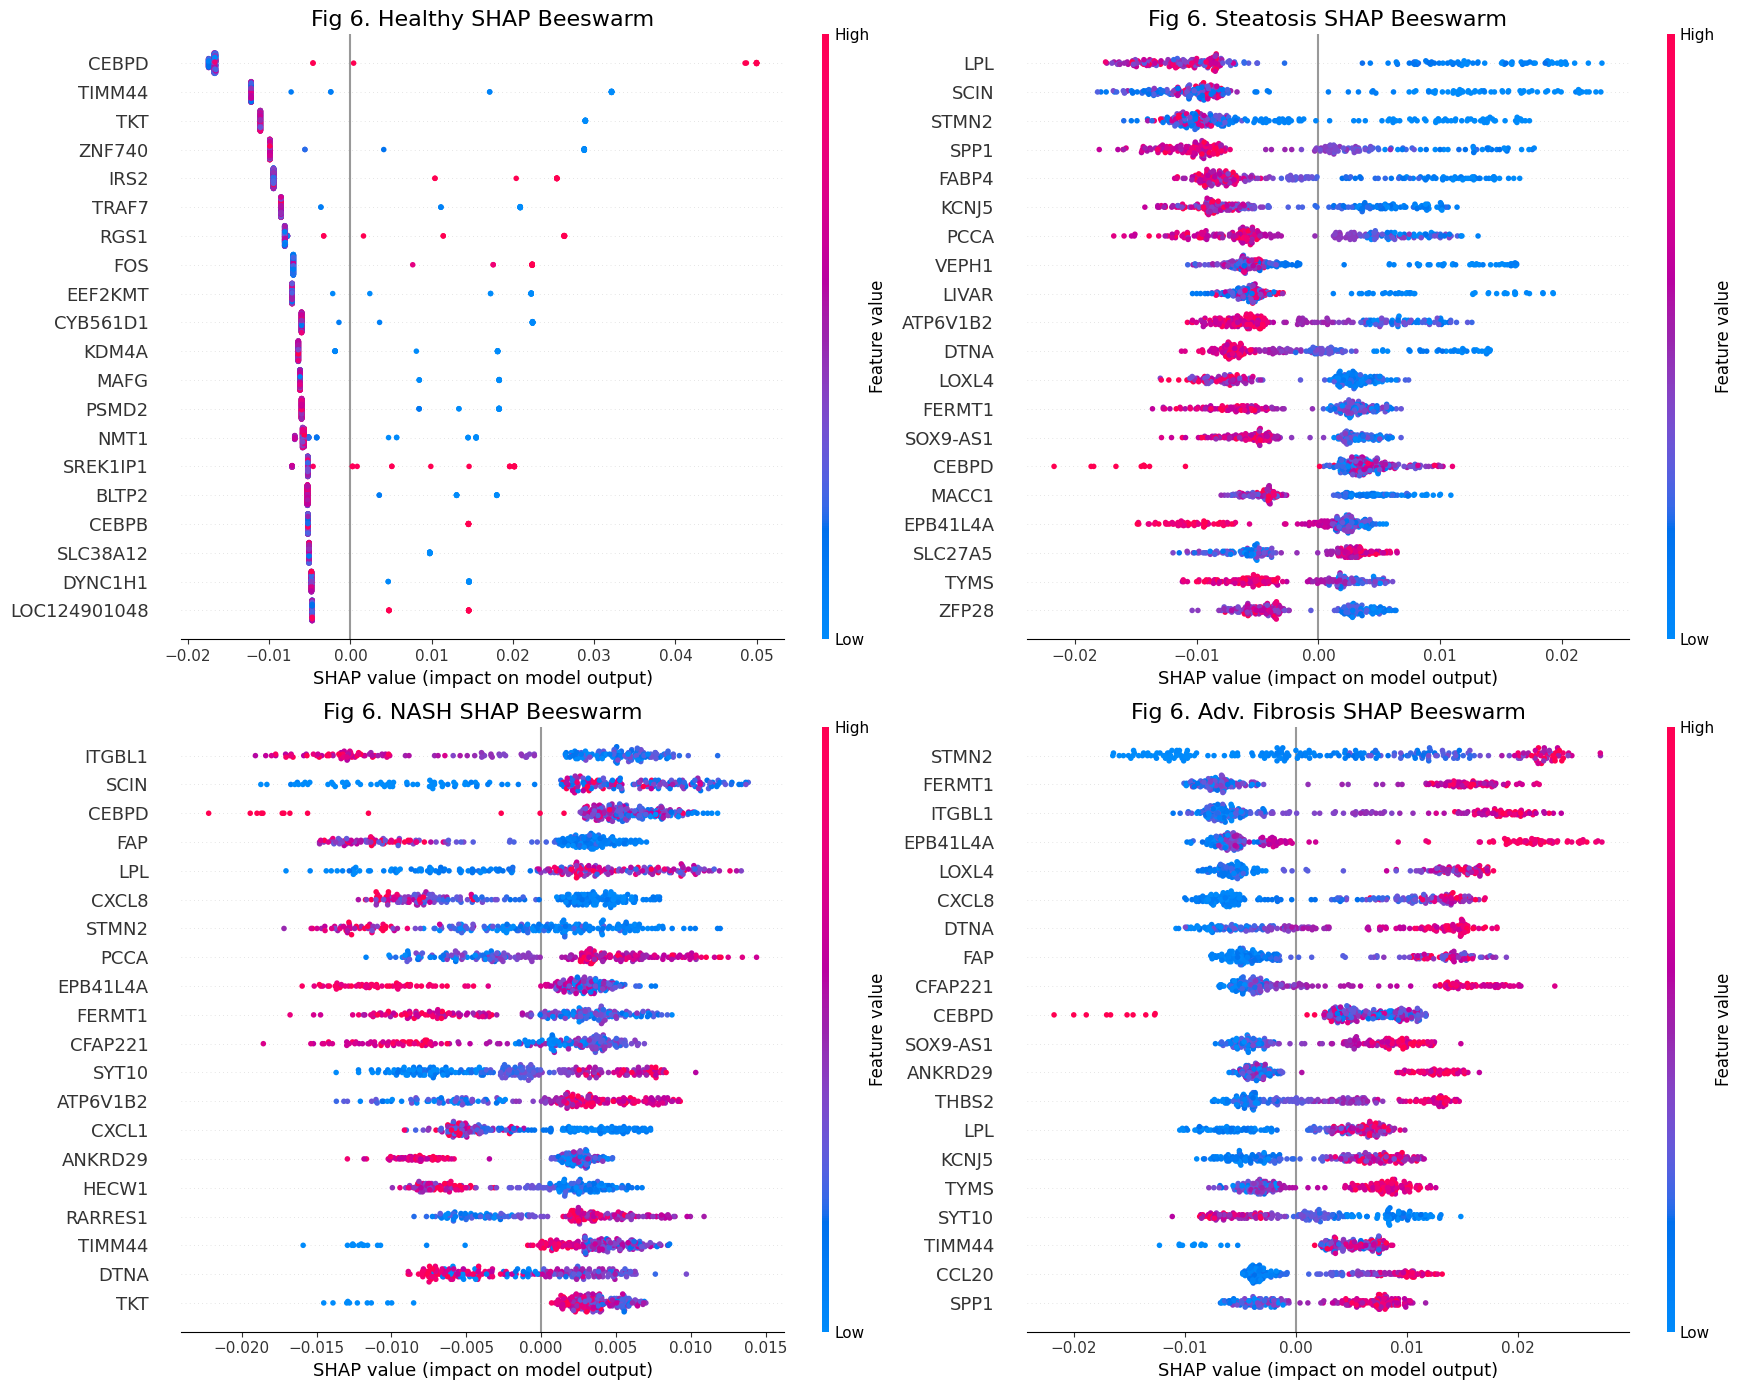

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig6_shap_per_class_beeswarm.png


In [17]:
# ### Fig 6 — SHAP Beeswarm Plots (Stage-Specific)
# Top 20 genes per class showing both magnitude and direction of impact.

fig = plt.figure(figsize=(18, 14))
for k, class_name in enumerate(CLASS_NAMES):
    plt.subplot(2, 2, k+1)
    # Get top genes for this class to limit the beeswarm
    class_data = final_shap_df[final_shap_df['class_id'] == k].head(20)
    top_genes_k = class_data['gene'].tolist()
    X_k = X[top_genes_k]
    sv_k = shap_values[k][:, [X.columns.get_loc(g) for g in top_genes_k]]
    
    shap.summary_plot(sv_k, X_k, show=False, plot_size=None)
    plt.title(f"Fig 6. {class_name} SHAP Beeswarm", fontsize=16)

plt.tight_layout()
fig_path = RESULTS_FIG / "fig6_shap_per_class_beeswarm.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

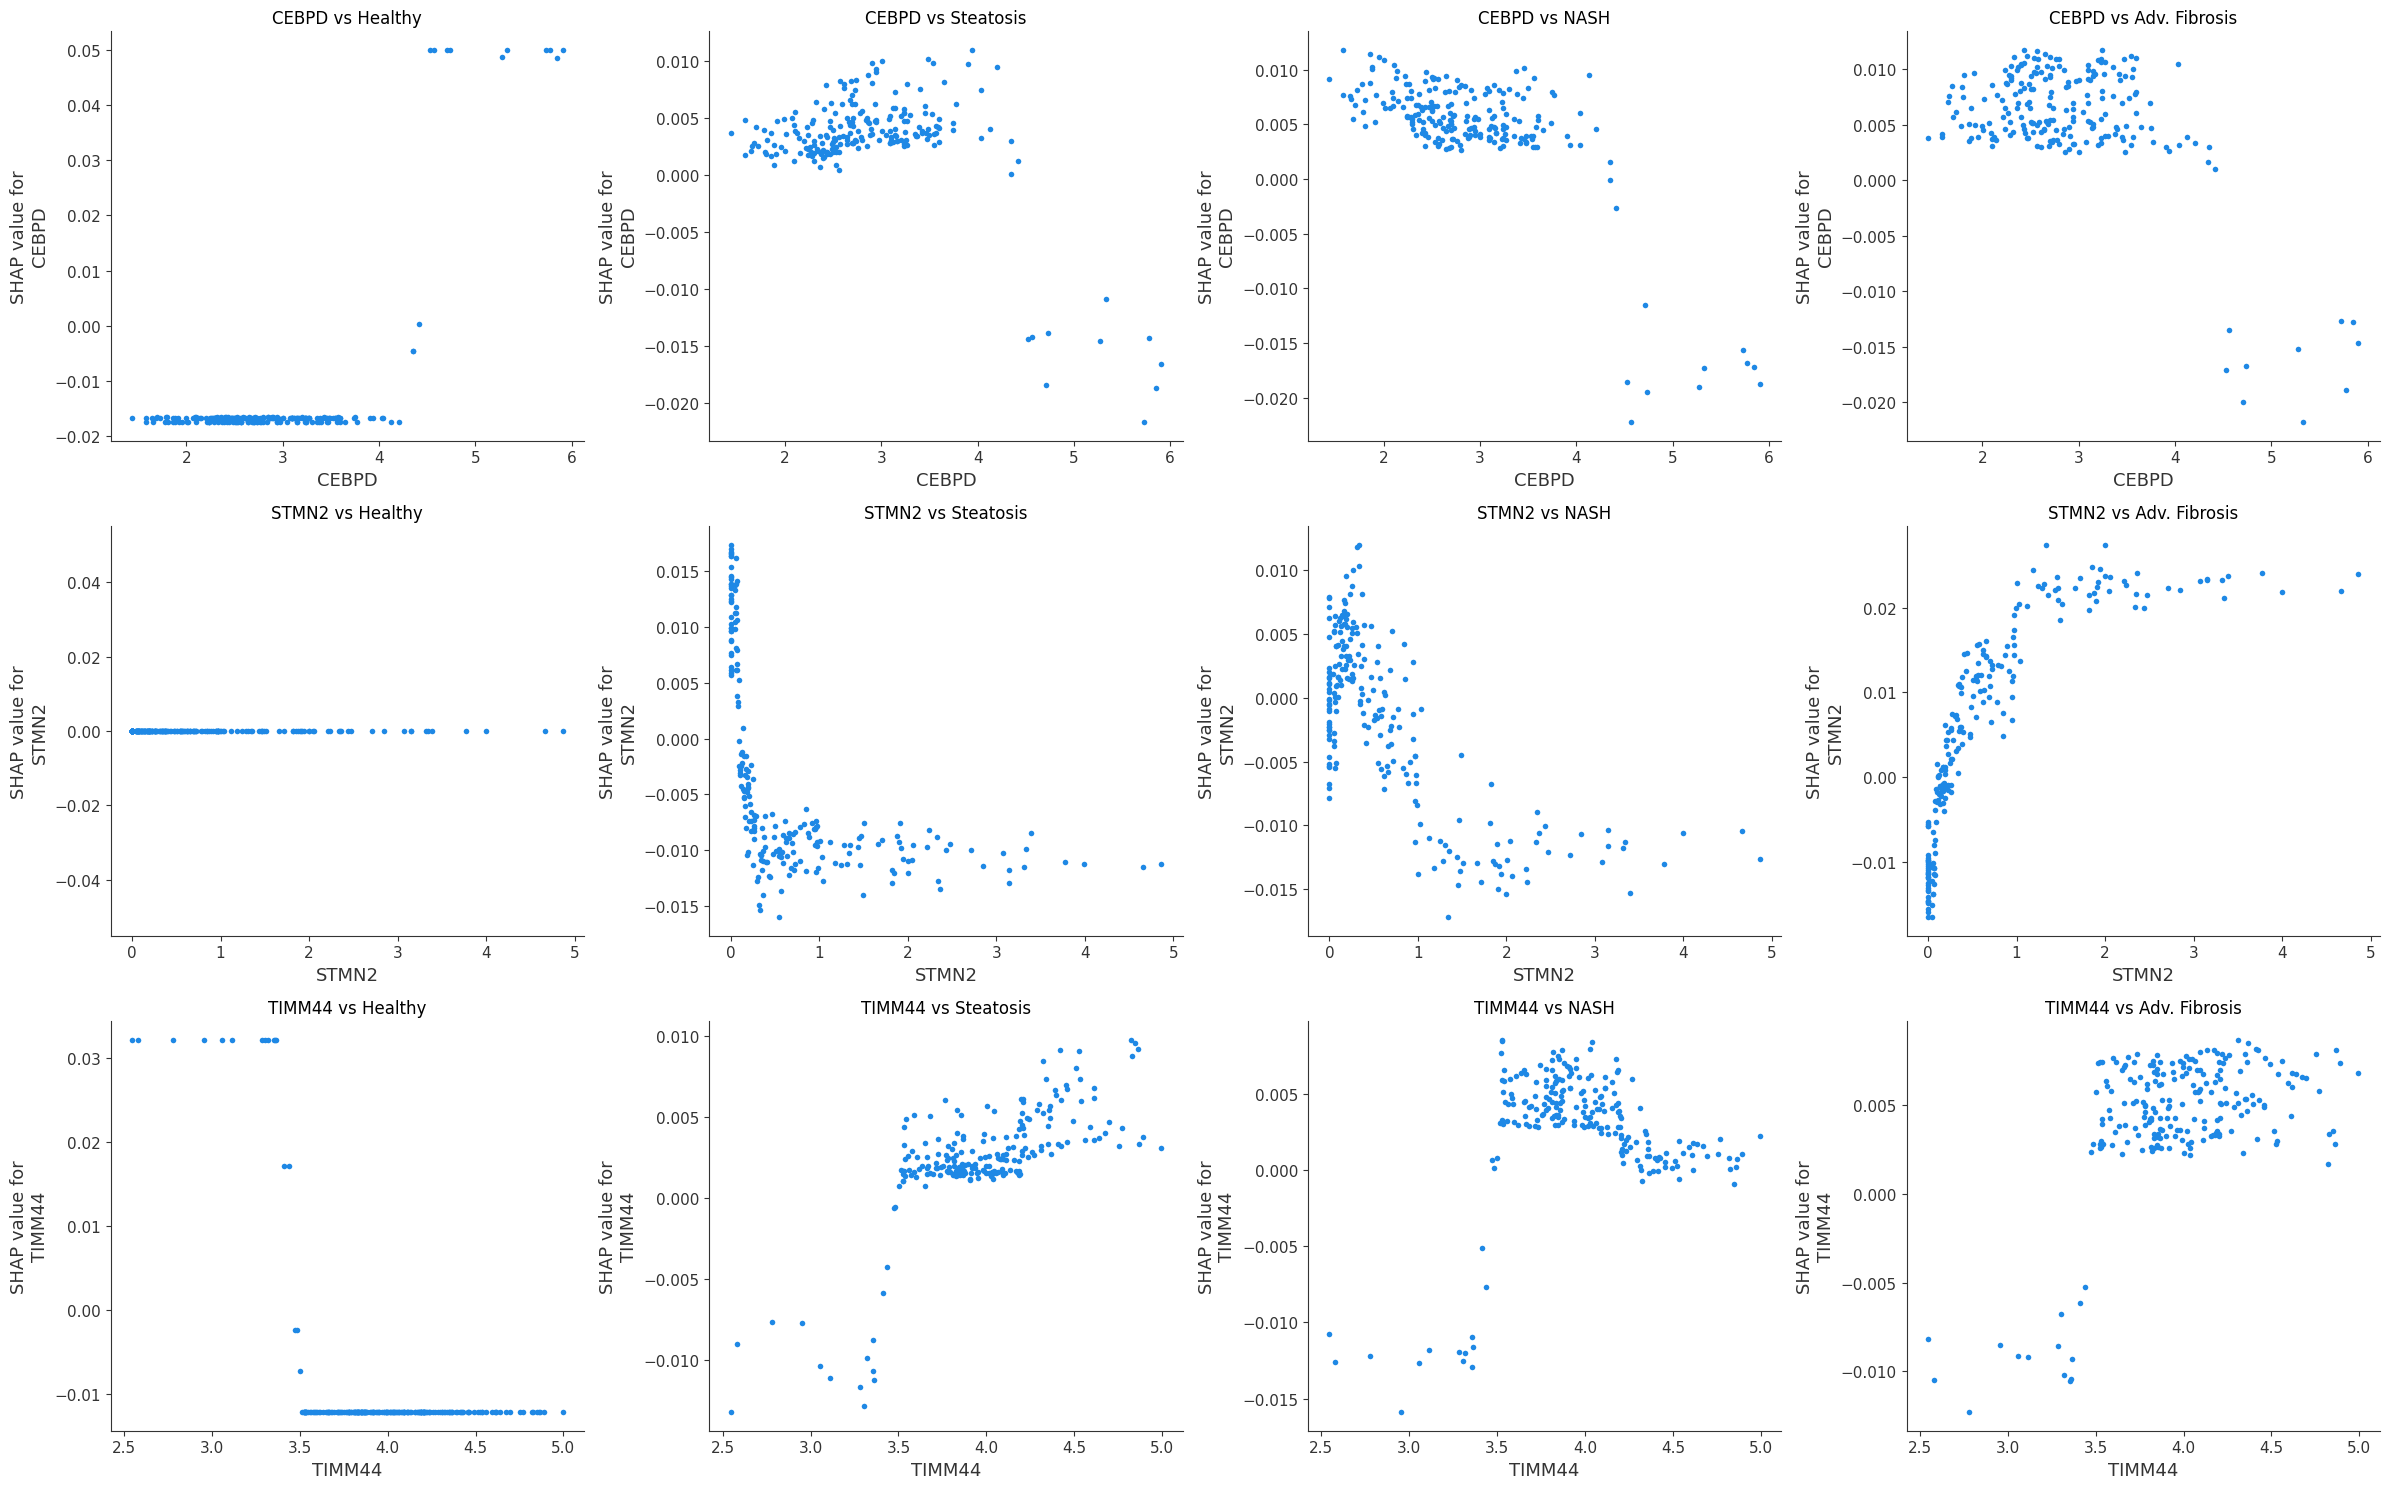

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig9_shap_dependence_plots.png


In [18]:
# ### Fig 9 — SHAP Dependence Plots (Top 3 Genes)
# Shows how gene expression level (X-axis) relates to the SHAP value (Y-axis).

# Find top 3 genes globally (mean of means across all classes)
global_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
top_3_idx = np.argsort(global_importance)[-3:][::-1]
top_3_genes = X.columns[top_3_idx].tolist()

fig, axes = plt.subplots(3, 4, figsize=(24, 15))

for i, gene in enumerate(top_3_genes):
    for k, class_name in enumerate(CLASS_NAMES):
        ax = axes[i, k]
        # Use shap.dependence_plot
        shap.dependence_plot(gene, shap_values[k], X, ax=ax, show=False, interaction_index=None)
        ax.set_title(f"{gene} vs {class_name}", fontsize=12)

plt.tight_layout()
fig_path = RESULTS_FIG / "fig9_shap_dependence_plots.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## 7. Global Summary (Supplementary)

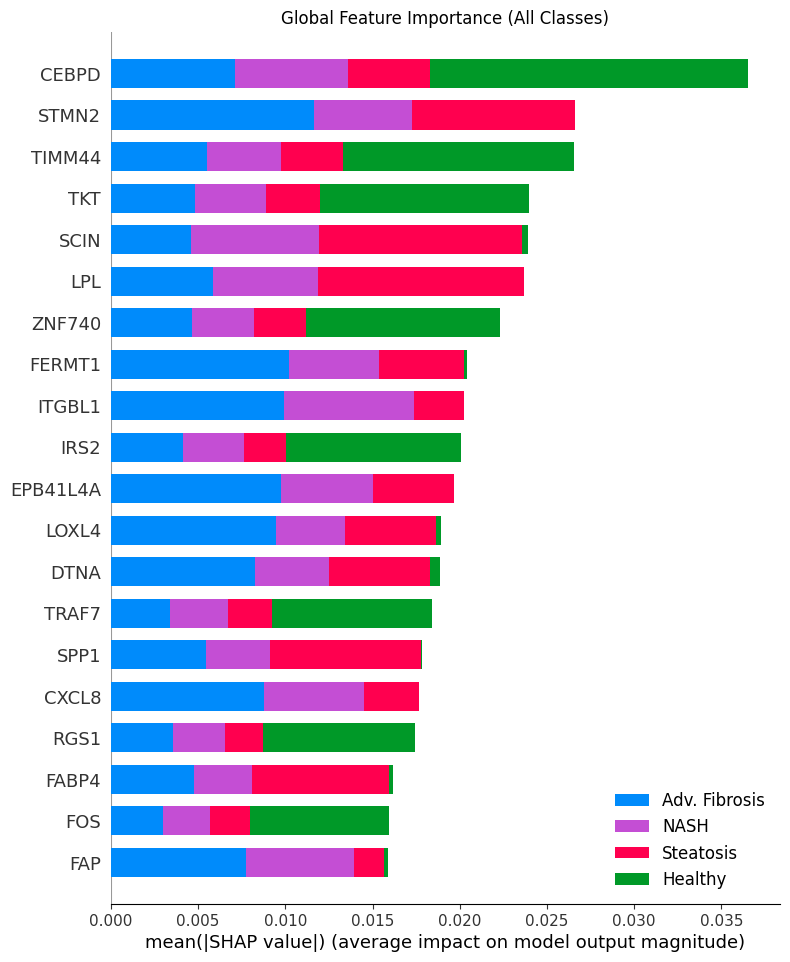

In [19]:
# Global beeswarm or summary plot (mean of means)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type="bar", class_names=CLASS_NAMES, show=False)
plt.title("Global Feature Importance (All Classes)")
fig_path = RESULTS_FIG / "shap_global_summary.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


## 8. Biological Interpretation

*(Note: Review the printed top genes and interpret their biological roles based on literature. Do not hallucinate biology.)*

### Class 0: Healthy
- The top predictors push the prediction towards a healthy state or absence of NAFLD signatures.

### Class 1: Simple Steatosis (NAFL)
- Expected biology: lipid metabolism, adipogenesis.

### Class 2: NASH
- Expected biology: inflammation, oxidative stress, immune cell infiltration.

### Class 3: Advanced Fibrosis
- Expected biology: ECM organization, collagen deposition, wound healing.


## Session Summary

**Notebook:** NB06 — SHAP Explainability

### What Was Accomplished
- Computed exact multi-class SHAP values for the best performing model.
- Extracted and saved the top stage-specific genes for each of the 4 progression classes.
- Generated the primary publication figure (2x2 per-class SHAP barplot).

### Outputs Saved
- `results/models/shap_values_class{k}.npy`
- `results/tables/top_shap_genes_per_class.csv`
- `results/figures/shap_per_class_barplot.png`
- `results/figures/shap_global_summary.png`

### Next Notebook Requires
- `top_shap_genes_per_class.csv` for downstream biological validation (GO/KEGG).
